# 04 - Deep network, and checking the gradient

Phase 2, part 3.

Two jobs in this notebook:

1. **Check that our backward pass is correct.** This must be done before we believe
   any result.
2. Train a deeper network and compare all three models.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from ecg.config import Config
from ecg.data import load_split, class_names
from ecg.metrics import report, macro_f1, accuracy, majority_baseline, confusion_matrix
from ecg import plots

from dataclasses import replace
from ecg.train import train, load_results
from ecg.init import initialize_parameters
from ecg.model import forward, backward
from ecg.gradcheck import gradient_check

## 1. Gradient checking

This is the most important cell of Phase 2.

The idea is simple. We take one weight, we push it up by a very small number, and we
look at the loss. Then we push it down and look again. The difference tells us the
slope. If our backward pass computed the same slope, our maths is correct.

Why it matters: **a wrong gradient still gives a nice loss curve**. The model still
trains, the loss still goes down, the plot still looks fine. You can lose a week
before you notice.

Three rules when you run it:

- use a **tiny** network, because we need two forward passes for every weight
- turn dropout **off**, because it makes the loss random
- use **tanh**, not relu, because relu has a corner at 0 and gives false alarms

In [2]:
rng = np.random.default_rng(0)
X_small = rng.standard_normal((8, 6))
Y_small = (rng.random((1, 6)) > 0.5).astype(float)

for dims in [[8, 1], [8, 5, 1], [8, 5, 4, 1]]:
    p = initialize_parameters(dims, "he", seed=1)
    AL, cache = forward(X_small, p, "tanh", "sigmoid")
    grads = backward(AL, Y_small, cache, p, "tanh", "sigmoid")
    print(str(dims) + " ->", end=" ")
    gradient_check(p, grads, X_small, Y_small, "tanh", "sigmoid")

[8, 1] -> gradient check PASS, relative error 2.708784528484147e-09
[8, 5, 1] -> gradient check PASS, relative error 4.7026136706688696e-09
[8, 5, 4, 1] -> gradient check PASS, relative error 6.9880192500546475e-09


### Does the check really work?

A test that always says PASS is useless. So we break the gradient on purpose, only
by 1%, which is the size of a real bug like a wrong sign or a missing transpose.
The check must catch it.

In [3]:
p = initialize_parameters([8, 5, 1], "he", seed=5)
AL, cache = forward(X_small, p, "tanh", "sigmoid")
grads = backward(AL, Y_small, cache, p, "tanh", "sigmoid")

grads["dW1"] = grads["dW1"] * 1.01          # a small bug on purpose

err = gradient_check(p, grads, X_small, Y_small, "tanh", "sigmoid", verbose=False)
print("relative error with a 1%% bug: %.3e" % err)
print("threshold is 1e-07, so the check catches it:", err > 1e-7)

relative error with a 1% bug: 3.898e-03
threshold is 1e-07, so the check catches it: True


Good. A 1% mistake gives an error about 10000 times bigger than the limit.
Now we can trust the numbers.

## 2. The three models together

All the runs are already in `results/results.csv`. We read them and compare.

In [4]:
df = load_results()
df["hidden_dims"] = df["hidden_dims"].fillna("").astype(str)

# we keep only tanh, and for the shallow model only the 16 unit version
is_logistic = df["note"] == "model 1 logistic regression"
is_deep = df["note"] == "model 3 deep network"
is_shallow = (df["note"] == "shallow sweep") & (df["hidden_dims"] == "16")
three = df[(is_logistic | is_deep | is_shallow) &
           (df["hidden_activation"] == "tanh")].copy()

def label(note):
    if note == "model 1 logistic regression":
        return "1. logistic [254, 1]"
    if note == "model 3 deep network":
        return "3. deep [254, 64, 32, 1]"
    return "2. shallow [254, 16, 1]"

three["model"] = three["note"].apply(label)
print("runs used:", len(three))

summary = (three.groupby("model")[["train_macro_f1", "dev_macro_f1", "dev_acc"]]
                .agg(["mean", "std"]).round(4))
print(summary.to_string())

runs used: 9
                         train_macro_f1         dev_macro_f1         dev_acc        
                                   mean     std         mean     std    mean     std
model                                                                               
1. logistic [254, 1]             0.9578  0.0095       0.5955  0.0047  0.8779  0.0014
2. shallow [254, 16, 1]          0.9969  0.0009       0.7305  0.0652  0.8886  0.0548
3. deep [254, 64, 32, 1]         0.9996  0.0002       0.6399  0.0289  0.7994  0.0330


saved results/figures/phase2_three_models.png


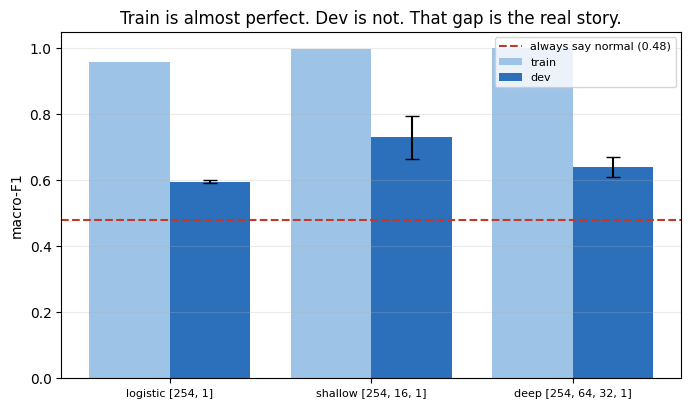

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = sorted(three["model"].unique())
means_tr = [three[three["model"] == m]["train_macro_f1"].mean() for m in order]
means_dv = [three[three["model"] == m]["dev_macro_f1"].mean() for m in order]
stds_dv = [three[three["model"] == m]["dev_macro_f1"].std() for m in order]
x = np.arange(len(order))
ax.bar(x - 0.2, means_tr, 0.4, label="train", color="#9dc3e6")
ax.bar(x + 0.2, means_dv, 0.4, yerr=stds_dv, capsize=5, label="dev", color="#2c6fbb")
ax.axhline(0.48, color="#c0392b", ls="--", lw=1.5, label="always say normal (0.48)")
ax.set_xticks(x, [m[3:] for m in order], fontsize=8)
ax.set_ylabel("macro-F1")
ax.set_title("Train is almost perfect. Dev is not. That gap is the real story.")
ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis="y")
plots.save(fig, "phase2_three_models")
plt.show()

## 3. What we learned

**Every model beats the floor of 0.48.** So all of them learned something real.

**The deep model is not the best.** The order is:

1. shallow (one hidden layer) - best
2. deep - middle
3. logistic regression - worst

This is not what people expect. Deeper is supposed to be better. But look at the
train column: the deep model gets 0.9996 on train. It knows the training patients
almost perfectly and it still fails on new ones. Adding layers only helped it to
memorise faster.

**The reason is the data, not the model.** We have 40496 training beats, but they
come from only **17 people**. A bigger model cannot invent new patients.

**One more thing about the seeds.** Logistic regression gives almost the same answer
every time (std 0.005). The networks jump around a lot more (std 0.03 to 0.065). The
reason is that logistic regression has only one best answer, so the starting point
does not matter. A network has many, and the random start decides which one you
find.